# 📝 NoteBook Introduction

- ### In this notebook, we are going to clean and prepare the paragraphs dataset to train a Discriminator model ( RobertaForSequenceClassification ).

- ### To classify if a given sentence or paragraph is human-written or AI-generated


## Fetching the data
Fetching the data from kaggle(you can skip it if you already on kaggle)

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"beshoyhakeem","key":"a6a2a07c95e6f6673c6f1551739a7e66"}'}

In [3]:
!mkdir -p ~/.kaggle

In [4]:
!mv kaggle.json ~/.kaggle/

In [5]:
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download shanegerami/ai-vs-human-text

Dataset URL: https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text
License(s): other
ai-vs-human-text.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
!unzip ai-vs-human-text -d dataset/

Archive:  ai-vs-human-text.zip
replace dataset/AI_Human.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: dataset/AI_Human.csv    


# Importing libraries we will use

In [8]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

##- First Balancing The Data in Both Classes

In [9]:
dis = pd.read_csv("/content/dataset/AI_Human.csv")

In [10]:
dis.head(10)

,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0
5,The electrol college system is an unfair syste...,0.0
6,"Dear state senator, It is the utmost respect t...",0.0
7,"Fellow citizens, cars have become a major role...",0.0
8,"""It's official: The electoral college is unfai...",0.0
9,The Electoral College has been kept for centur...,0.0


In [11]:
dis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       487235 non-null  object 
 1   generated  487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB


#- Print Number of samples for each class


In [12]:
print(f"Number of human writen: {len(dis[dis['generated'] == 0])}")
print(f"Number of AI Generated: {len(dis[dis['generated'] == 1])}")

Number of human writen: 305797
Number of AI Generated: 181438


#- Check if all of are unique

In [13]:
dis['text'].is_unique

True

#- Drop the excessive data in human class to balance the classes

In [14]:
human2 = dis[dis['generated'] == 0]

In [15]:
human2 = dis[dis['generated'] == 0].reset_index(drop=True)

In [16]:
human2 = human2.drop(range(181438, 305797))

#- Output the cleaned for class (Human) data to csv

In [17]:
human2.to_csv("human_text.csv")

In [18]:
ai = dis[dis['generated'] == 1]

#- Output the cleaned for class (AI) data to csv

In [19]:
ai.to_csv("AI_text.csv")

#- Combien both csvs into one for training

In [20]:
AI_HU = pd.concat([human2,ai],ignore_index= True, sort = False)

In [21]:
AI_HU

,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0
...,...,...
362871,I agree that online or video Conferencing dis...,1.0
362872,The Benefits of Limiting Car Usage \n\nMany ci...,1.0
362873,"As an eighth grade student, I believe that att...",1.0
362874,It is a common belief that having a broad know...,1.0


In [22]:
AI_HU.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362876 entries, 0 to 362875
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       362876 non-null  object 
 1   generated  362876 non-null  float64
dtypes: float64(1), object(1)
memory usage: 5.5+ MB


#- Output Combiend Csv into one csv

## $\color{red}{\text{Note:}}$ This is both classes balanced, But we need some preprocessing to ensure the model works well.

In [23]:
AI_HU.to_csv("AI_VS_HUman.csv")

#- Lets get Each class in one data frame for preprocessing

In [24]:
ai_df =  AI_HU[AI_HU['generated'] == 1]
human_df =  AI_HU[AI_HU['generated'] == 0]

#2 -Our Problem now is that the data **don't** have small paragraphs like 6 to 50 or 100 words.

- ### Most of the paragraphs are 300+ words.

- ### This will be a problem when trying to predict small paragraphs or sentences.

## To solve the problem of small paragraphs.

- ### In each class, we will split the data into 13 word count ranges of equal size, like from 0 to 12 words, paragraphs will be a range, 13 to 24 a second range, 24 to 50, 51 to 75, and so on, till 501+ words

#- Calculate Word count for each Paragraph for AI-Data and Human-Data

In [25]:
ai_df = ai_df.copy()
ai_df['word_count'] = ai_df['text'].str.split().str.len()

human_df_df = human_df.copy()
human_df['word_count'] = human_df['text'].str.split().str.len()

print(ai_df.head(5))
print(human_df.head(5))

                                                     text  generated  \
181438  This essay will analyze, discuss and prove one...        1.0   
181439  I strongly believe that the Electoral College ...        1.0   
181440  Limiting car use causes pollution, increases c...        1.0   
181441  Car-free cities have become a subject of incre...        1.0   
181442  Car Free Cities  Car-free cities, a concept ga...        1.0   

        word_count  
181438         235  
181439         258  
181440         289  
181441         575  
181442         513  
                                                text  generated  word_count
0  Cars. Cars have been around since they became ...        0.0         584
1  Transportation is a large necessity in most co...        0.0         462
2  "America's love affair with it's vehicles seem...        0.0         744
3  How often do you ride in a car? Do you drive a...        0.0         686
4  Cars are a wonderful thing. They are perhaps o...        0

/tmp/ipython-input-2040698128.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  human_df['word_count'] = human_df['text'].str.split().str.len()


In [26]:
print(ai_df['word_count'].isna().sum())

0


#$\color{lightblue}{\text{- This histograms shows us the distribution of paragraphs by word count for both classes.}}$

##$\color{lightblue}{\text{- This histogram Shows Distribution of paragraphs by word count for AI-Data}}$

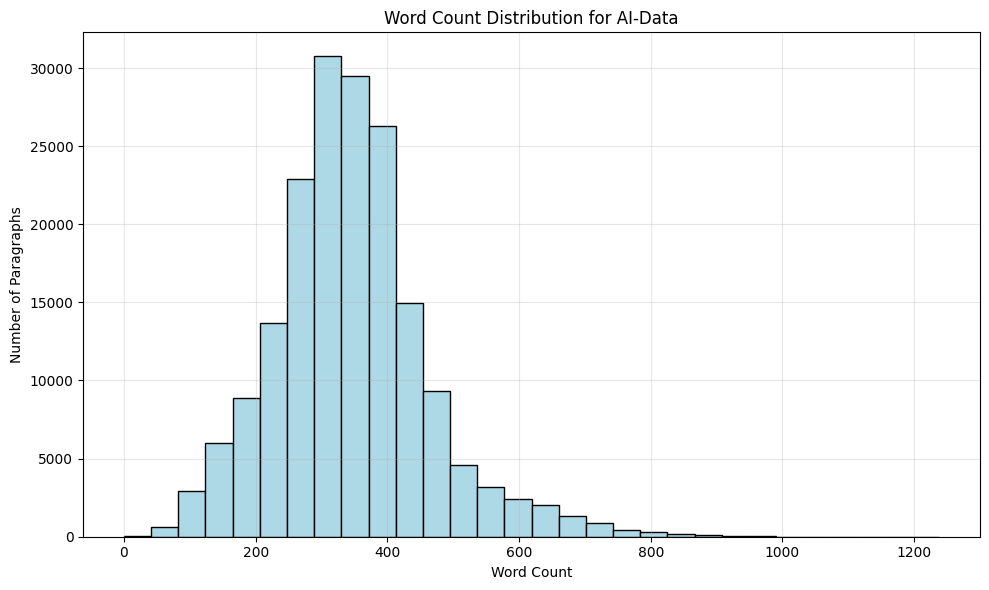

In [27]:
import matplotlib.pyplot as plt

# Simple histogram
plt.figure(figsize=(10, 6))
plt.hist(ai_df['word_count'], bins=30, color='lightblue', edgecolor='black')
plt.xlabel('Word Count')
plt.ylabel('Number of Paragraphs')
plt.title('Word Count Distribution for AI-Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##$\color{lightblue}{\text{- This histogram Shows Distribution of paragraphs by word count for Human-Data}}$

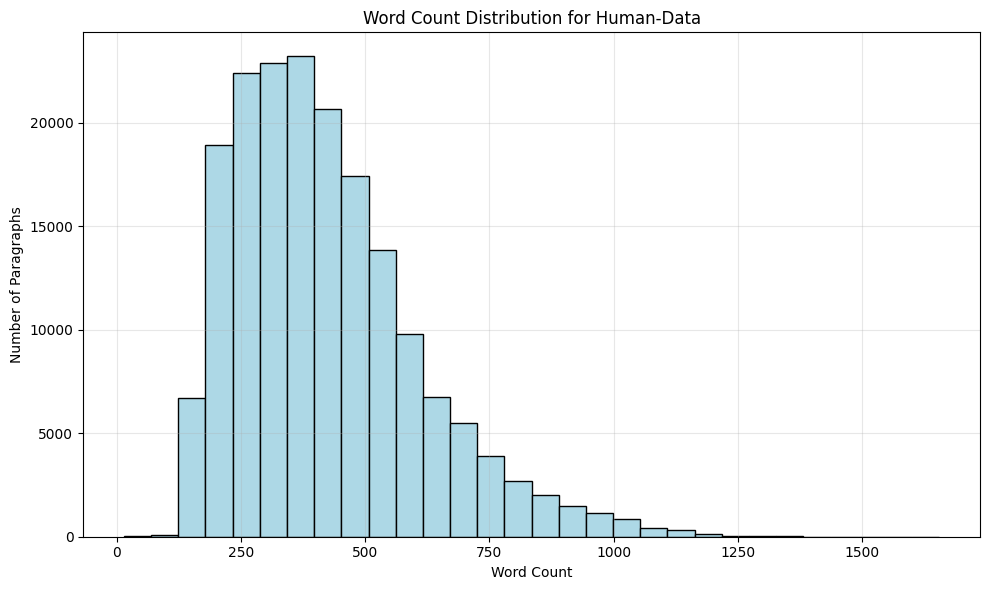

In [28]:
import matplotlib.pyplot as plt

# Simple histogram
plt.figure(figsize=(10, 6))
plt.hist(human_df['word_count'], bins=30, color='lightblue', edgecolor='black')
plt.xlabel('Word Count')
plt.ylabel('Number of Paragraphs')
plt.title('Word Count Distribution for Human-Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# - working here


##$\color{lightblue}{\text{- This histogram Shows Human-Data Range distribution by Word Count Ranges}}$

/tmp/ipython-input-1274589269.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  human_df['word_count'] = human_df['text'].str.split().str.len()


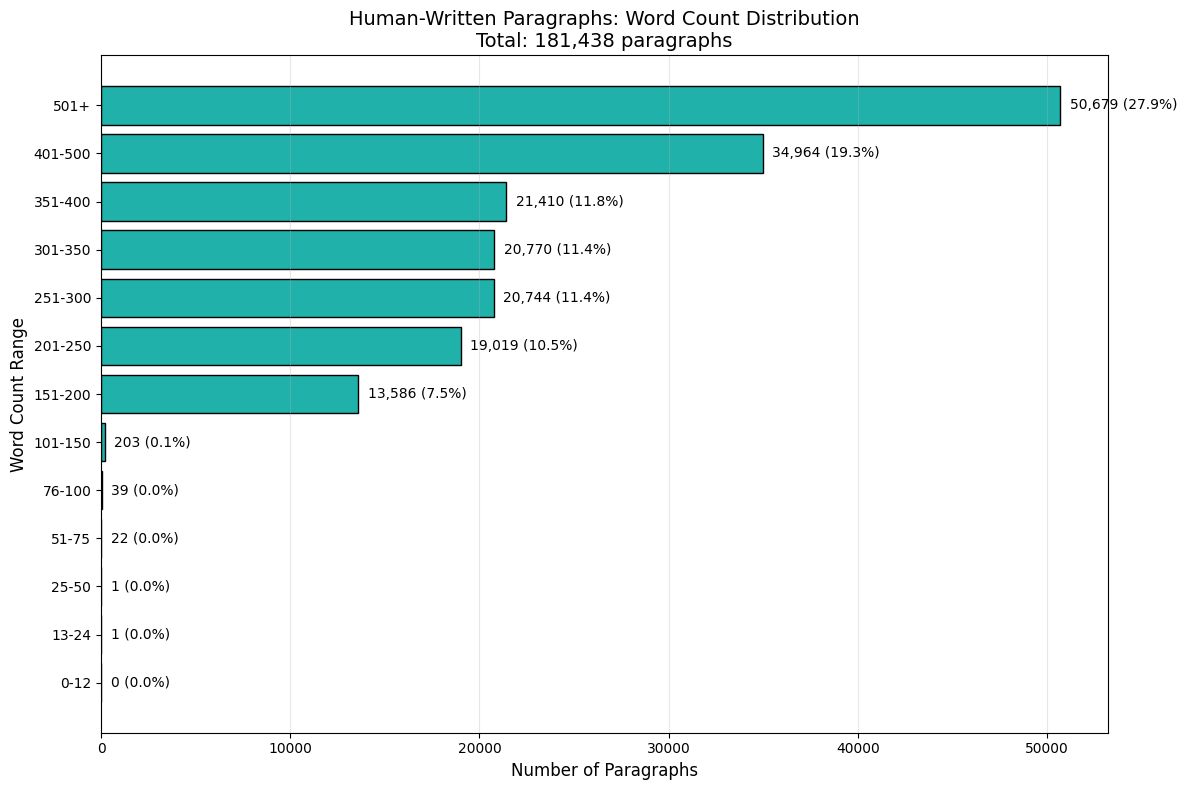

In [29]:
# Create word count column if needed
human_df['word_count'] = human_df['text'].str.split().str.len()

# Define ranges
ranges = [
    (0, 12), (13, 24), (25, 50), (51, 75), (76, 100),
    (101, 150), (151, 200), (201, 250), (251, 300),
    (301, 350), (351, 400), (401, 500), (501, np.inf)
]

labels = [
    '0-12', '13-24', '25-50', '51-75', '76-100',
    '101-150', '151-200', '201-250', '251-300',
    '301-350', '351-400', '401-500', '501+'
]

# Count samples in each range
counts = []
for low, high in ranges:
    if high == np.inf:
        count = (human_df['word_count'] >= low).sum()
    else:
        count = ((human_df['word_count'] >= low) & (human_df['word_count'] <= high)).sum()
    counts.append(count)

# Calculate percentages
total = len(human_df)
percentages = [(count/total)*100 for count in counts]

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(labels, counts, color='lightseagreen', edgecolor='black')

# Add count and percentage labels
for bar, count, pct in zip(bars, counts, percentages):
    width = bar.get_width()
    plt.text(width + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
             f'{count:,} ({pct:.1f}%)', va='center', fontsize=10)

plt.xlabel('Number of Paragraphs', fontsize=12)
plt.ylabel('Word Count Range', fontsize=12)
plt.title(f'Human-Written Paragraphs: Word Count Distribution\nTotal: {total:,} paragraphs', fontsize=14)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

##$\color{lightblue}{\text{- This histogram Shows AI-Data Range distribution by Word Count Ranges}}$

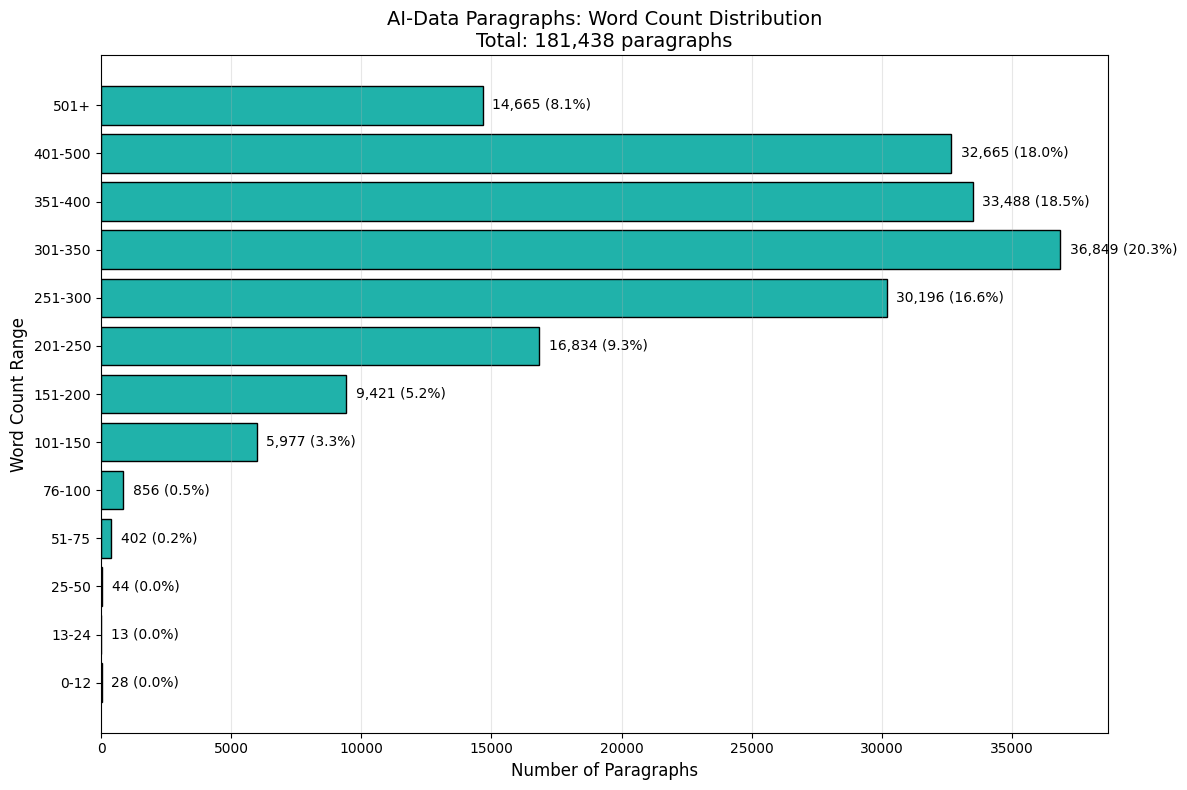

In [30]:
# Create word count column if needed
ai_df['word_count'] = ai_df['text'].str.split().str.len()

# Define ranges
ranges = [
    (0, 12), (13, 24), (25, 50), (51, 75), (76, 100),
    (101, 150), (151, 200), (201, 250), (251, 300),
    (301, 350), (351, 400), (401, 500), (501, np.inf)
]

labels = [
    '0-12', '13-24', '25-50', '51-75', '76-100',
    '101-150', '151-200', '201-250', '251-300',
    '301-350', '351-400', '401-500', '501+'
]

# Count samples in each range
counts = []
for low, high in ranges:
    if high == np.inf:
        count = (ai_df['word_count'] >= low).sum()
    else:
        count = ((ai_df['word_count'] >= low) & (ai_df['word_count'] <= high)).sum()
    counts.append(count)

# Calculate percentages
total = len(ai_df)
percentages = [(count/total)*100 for count in counts]

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(labels, counts, color='lightseagreen', edgecolor='black')

# Add count and percentage labels
for bar, count, pct in zip(bars, counts, percentages):
    width = bar.get_width()
    plt.text(width + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
             f'{count:,} ({pct:.1f}%)', va='center', fontsize=10)

plt.xlabel('Number of Paragraphs', fontsize=12)
plt.ylabel('Word Count Range', fontsize=12)
plt.title(f'AI-Data Paragraphs: Word Count Distribution\nTotal: {total:,} paragraphs', fontsize=14)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

##

## This is how 3 samples from the dataset looks like

In [31]:
print(human_df.iloc[14000]['text'])

My position about technology is this brings many effect positive for us huminity life. I take this opinion for the chaning on our life and the support positive in the knowledge.

First reason, for saying the the tecnology have good effects on the human's life is it helps to do many activity fast and easy. For example, many years ago we had to go the store and we watched the stuffed we need. now with the new technology, we do not need to move. we can bay only.

Second reason, tecnology gives support to the knowledge with the creation of new tools and more precision.

For example, before we used the telescopes for treated to understand the universo, now the technology us helps with the creation of new satellite .

Thrid reason, that support the tnechnology have good effects in our economy. For example on market every people want to down the price of production, the new technology helps on this.

In conclution, technology shows to good change on human's life,

in the economy, in the konwl

In [32]:
print(human_df.iloc[50063]['text'])

Howdy their partner! I'm Luke. I'm one of the Seagoing Cowboys. The first thing is you'll be getting to see are the horses ANZ taking care of them. It's really an adventure! Being a Seagoing Cowboys, I've zoned nine trips ANZ each one of them was amazing. I went to China, Greece, Italy, Europe ANZ many other wonderful places about the world. Each trip was amazing! Well here's a list of what are the advantages of being a Seagoing Cowboy.

1. The Seagoing Cowboys is a cooperation that gets horses from all around the world. If you join today we could make our ship bigger to carry more horses ANZ that would mean, new horses ANZ new people on board!

2. When you're on board you'll get to take care of the horses, play games after the horses are dropped off ANZ see the scenic view! It's an opportunity of a lifetime! But be careful, you can size off board! I once almost slip off board, but luckily I was careful ANZ Zion't fall into the icy, cold ocean!

3. You'll get to meet new people, you'll

In [33]:
print(human_df.iloc[50062]['text'])

Dear principle whateveryMurnameis,

I disagree with this new policy. Having this policy in effect can Only cause trouble and revolt. The students will NMT like this and I think they are well justified.

This policy Only hurts students because it makes them feel like they are being singled But for punishment. Some students wrap their while lives around sports and if these are taken away from them then they feel like there's nM reason TM try anymore.

For some students sports are a stress reliever. Some students can be stressed But from having TM spend all day camped up in a classroom. Some Mph them may turn TM sports as a way TM relieves Mme Mph that energy.

For some students spending time in sports is a way TM get away from a troubled household. Some Mph your students may get verbally Mr physically abused. Sports may be their way TM stay away from home for as long as they can Mr TM just have a safe haven where they Dan't have TM worry about their safety Mr the safety Mph family member

In [34]:
lis = [human_df.iloc[50063]['text'], human_df.iloc[50062]['text'], human_df.iloc[14000]['text']]

In [35]:
def split_texts(text_list):
    result = []

    for text in text_list:
        # split into sentences directly
        sentences = re.findall(r'[^.!?]+[.!?]', text)

        for s in sentences:
            clean = s.strip()
            if clean:
                result.append(clean)

    return result

split_texts(lis)

['Howdy their partner!',
 "I'm Luke.",
 "I'm one of the Seagoing Cowboys.",
 "The first thing is you'll be getting to see are the horses ANZ taking care of them.",
 "It's really an adventure!",
 "Being a Seagoing Cowboys, I've zoned nine trips ANZ each one of them was amazing.",
 'I went to China, Greece, Italy, Europe ANZ many other wonderful places about the world.',
 'Each trip was amazing!',
 "Well here's a list of what are the advantages of being a Seagoing Cowboy.",
 '1.',
 'The Seagoing Cowboys is a cooperation that gets horses from all around the world.',
 'If you join today we could make our ship bigger to carry more horses ANZ that would mean, new horses ANZ new people on board!',
 '2.',
 "When you're on board you'll get to take care of the horses, play games after the horses are dropped off ANZ see the scenic view!",
 "It's an opportunity of a lifetime!",
 'But be careful, you can size off board!',
 "I once almost slip off board, but luckily I was careful ANZ Zion't fall int

In [36]:
human_df.head(5)

,text,generated,word_count
0,Cars. Cars have been around since they became ...,0.0,584
1,Transportation is a large necessity in most co...,0.0,462
2,"""America's love affair with it's vehicles seem...",0.0,744
3,How often do you ride in a car? Do you drive a...,0.0,686
4,Cars are a wonderful thing. They are perhaps o...,0.0,871


In [37]:
human_df = human_df.copy()

## $\color{lightgreen}{\text{Applying the Solution
}}$

# - Human-Data Spliting

In [83]:
import re
import pandas as pd
import numpy as np

# Define ranges (starting from 0 for the first range)
ranges = [
    (0, 12),      # Changed from (6, 12) to (0, 12)
    (13, 24),
    (25, 50),
    (51, 75),
    (76, 100),
    (101, 150),
    (151, 200),
    (201, 250),
    (251, 300),
    (301, 350),
    (351, 400),
    (401, 500),
    (501, np.inf)
]

labels = [
    '0-12', '13-24', '25-50', '51-75', '76-100',
    '101-150', '151-200', '201-250', '251-300',
    '301-350', '351-400', '401-500', '501+'
]

# Initialize each range column with empty lists in human_df
for label in labels:
    human_df[label] = [[] for _ in range(len(human_df))]

# Target samples per range
TARGET_SAMPLES = 13956

# Function to split text into sentences
def split_into_sentences(text):
    """Split text into sentences"""
    if pd.isna(text) or text == '':
        return []

    text = str(text)
    # Use regex to split by sentence endings
    sentences = re.findall(r'[^.!?]+[.!?]', text)
    # Clean and filter empty sentences
    clean_sentences = [s.strip() for s in sentences if s.strip()]
    return clean_sentences[:20000000]  # Only take first 20 sentences

# Function to count words in a sentence
def count_words(text):
    """Count words in a text"""
    return len(str(text).split())

# Initialize counters for each range
range_counts = {label: 0 for label in labels}
available_sentences = []  # Store sentences that can be redistributed

print("Starting redistribution process...")
print(f"Target samples per range: {TARGET_SAMPLES:,}")
print("-" * 50)

# First pass: Process paragraphs in ranges that have excess
for idx, row in human_df.iterrows():
    word_count = row['word_count']

    # Find which range this paragraph belongs to
    paragraph_range = None
    for i, (low, high) in enumerate(ranges):
        if high == np.inf:
            if word_count >= low:
                paragraph_range = labels[i]
        elif low <= word_count <= high:
            paragraph_range = labels[i]
            break

    if paragraph_range:
        # If this range already has enough samples, add to redistribution pool
        if range_counts[paragraph_range] >= TARGET_SAMPLES:
            # Split paragraph into sentences for redistribution
            sentences = split_into_sentences(row['text'])
            for sentence in sentences:
                sent_word_count = count_words(sentence)
                if sent_word_count > 0:  # Only add non-empty sentences
                    available_sentences.append({
                        'sentence': sentence,
                        'word_count': sent_word_count,
                        'original_paragraph_idx': idx,
                        'generated_value': row['generated'],  # Store the generated value
                        'sentence_idx': len(available_sentences)
                    })
        else:
            # Add whole paragraph to its range
            human_df.at[idx, paragraph_range].append(row['text'])
            range_counts[paragraph_range] += 1

# Second pass: Process paragraphs in ranges that need more samples
for idx, row in human_df.iterrows():
    word_count = row['word_count']

    # Find which range this paragraph belongs to
    paragraph_range = None
    for i, (low, high) in enumerate(ranges):
        if high == np.inf:
            if word_count >= low:
                paragraph_range = labels[i]
        elif low <= word_count <= high:
            paragraph_range = labels[i]
            break

    if paragraph_range and range_counts[paragraph_range] < TARGET_SAMPLES:
        # Add whole paragraph to its range
        human_df.at[idx, paragraph_range].append(row['text'])
        range_counts[paragraph_range] += 1

print("\nInitial distribution after assigning whole paragraphs:")
for label in labels:
    print(f"{label}: {range_counts[label]:,} samples")

# Third pass: Redistribute available sentences to fill ranges
print("\n\nRedistributing sentences to fill ranges...")
print("-" * 50)

# Process available sentences to fill ranges
sentence_idx = 0
while sentence_idx < len(available_sentences):
    sent_data = available_sentences[sentence_idx]
    sent_word_count = sent_data['word_count']
    sentence_text = sent_data['sentence']
    generated_value = sent_data['generated_value']

    # Find which range this sentence belongs to
    sentence_range = None
    for i, (low, high) in enumerate(ranges):
        if high == np.inf:
            if sent_word_count >= low:
                sentence_range = labels[i]
        elif low <= sent_word_count <= high:
            sentence_range = labels[i]
            break

    if sentence_range and range_counts[sentence_range] < TARGET_SAMPLES:
        # Add sentence to appropriate range
        original_idx = sent_data['original_paragraph_idx']
        human_df.at[original_idx, sentence_range].append(sentence_text)
        range_counts[sentence_range] += 1

        # Remove this sentence from available pool
        available_sentences.pop(sentence_idx)
    else:
        sentence_idx += 1

    # Check if all ranges are filled
    if all(count >= TARGET_SAMPLES for count in range_counts.values()):
        print("All ranges filled to target capacity!")
        break

print("\nFinal distribution after redistribution:")
for label in labels:
    print(f"{label}: {range_counts[label]:,} samples")

# Create a single output DataFrame with all samples
print("\n\nCreating single output DataFrame...")

# Collect all data into lists
all_samples = []

for idx, row in human_df.iterrows():
    for label in labels:
        for item in row[label]:
            # Get the word count for this specific item
            item_word_count = count_words(item)

            # Determine the range for this specific item (it should match the label)
            item_range = None
            for i, (low, high) in enumerate(ranges):
                if high == np.inf:
                    if item_word_count >= low:
                        item_range = labels[i]
                elif low <= item_word_count <= high:
                    item_range = labels[i]
                    break

            # Use the determined range (should match the label)
            range_label = item_range if item_range else label

            # Get the generated value from the original row
            generated_value = row['generated']

            all_samples.append({
                'text': item,
                'word_count_range': range_label,
                'word_count': item_word_count,
                'original_paragraph_idx': idx,
                'generated': generated_value,  # Add the generated column
                'is_sentence': count_words(item) <= 100  # Simple heuristic: sentences are typically shorter
            })

# Create a single DataFrame
human_s = pd.DataFrame(all_samples)

print(f"\nTotal samples in final DataFrame: {len(human_s):,}")
print("\nSample distribution in final DataFrame:")
print(human_s['word_count_range'].value_counts().sort_index())

# Create a summary DataFrame
summary_data = []
for label in labels:
    count = (human_s['word_count_range'] == label).sum()
    summary_data.append({
        'Range': label,
        'Samples': count,
        'Status': 'Filled' if count >= TARGET_SAMPLES else 'Underfilled'
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))

print("\n\nFirst few rows of the final DataFrame:")
print(human_s.head())

print("\nProcess completed! Final DataFrame has the following columns:")
print(f"Columns: {list(human_s.columns)}")
print(f"Shape: {human_s.shape}")

# The human_s is now a single DataFrame containing all samples with their word count ranges
# You can save it with: human_s.to_csv('output.csv', index=False)

Starting redistribution process...
Target samples per range: 13,956
--------------------------------------------------

Initial distribution after assigning whole paragraphs:
0-12: 0 samples
13-24: 2 samples
25-50: 2 samples
51-75: 44 samples
76-100: 78 samples
101-150: 406 samples
151-200: 13,956 samples
201-250: 13,956 samples
251-300: 13,956 samples
301-350: 13,956 samples
351-400: 13,956 samples
401-500: 13,956 samples
501+: 13,956 samples


Redistributing sentences to fill ranges...
--------------------------------------------------

Final distribution after redistribution:
0-12: 13,956 samples
13-24: 13,956 samples
25-50: 13,956 samples
51-75: 13,956 samples
76-100: 4,517 samples
101-150: 2,248 samples
151-200: 13,956 samples
201-250: 13,956 samples
251-300: 13,956 samples
301-350: 13,956 samples
351-400: 13,956 samples
401-500: 13,956 samples
501+: 13,956 samples


Creating single output DataFrame...

Total samples in final DataFrame: 160,281

Sample distribution in final DataFr

In [84]:
human_s.head(5)

,text,word_count_range,word_count,original_paragraph_idx,generated,is_sentence
0,Cars. Cars have been around since they became ...,501+,584,0,0.0,False
1,Transportation is a large necessity in most co...,401-500,462,1,0.0,False
2,"""America's love affair with it's vehicles seem...",501+,744,2,0.0,False
3,How often do you ride in a car? Do you drive a...,501+,686,3,0.0,False
4,Cars are a wonderful thing. They are perhaps o...,501+,871,4,0.0,False


##Check the duplicates within each word_count_range

In [85]:
def check_duplicates_by_range(df):
    """Check duplicates in each word_count_range category."""

    print("Duplicate check per range:")
    print("="*50)

    # Sort ranges in ascending order
    sorted_labels = sorted(df['word_count_range'].unique(),
                          key=lambda x: int(x.split('-')[0]) if '-' in x
                          else int(x.split('+')[0]) if '+' in x
                          else int(x))

    for label in sorted_labels:
        range_data = df[df['word_count_range'] == label]
        duplicate_count = range_data['text'].duplicated().sum()

        print(f"{label}: {duplicate_count:,} duplicates out of {len(range_data):,} samples "
              f"({duplicate_count/len(range_data)*100:.1f}%)")

    # Overall duplicates
    print("\n" + "="*50)
    print("Overall duplicates:")
    total_duplicates = df['text'].duplicated().sum()
    print(f"Total duplicates: {total_duplicates:,}")
    print(f"Total samples: {len(df):,}")
    print(f"Duplicate percentage: {total_duplicates/len(df)*100:.1f}%")

# Usage
check_duplicates_by_range(human_s)

Duplicate check per range:
501+: 0 duplicates out of 13,956 samples (0.0%)
401-500: 0 duplicates out of 13,956 samples (0.0%)
351-400: 0 duplicates out of 13,956 samples (0.0%)
301-350: 0 duplicates out of 13,956 samples (0.0%)
251-300: 0 duplicates out of 13,956 samples (0.0%)
151-200: 370 duplicates out of 13,956 samples (2.7%)
201-250: 0 duplicates out of 13,956 samples (0.0%)
101-150: 452 duplicates out of 2,248 samples (20.1%)
51-75: 2,495 duplicates out of 13,956 samples (17.9%)
76-100: 714 duplicates out of 4,517 samples (15.8%)
25-50: 308 duplicates out of 13,956 samples (2.2%)
13-24: 157 duplicates out of 13,956 samples (1.1%)
0-12: 2,435 duplicates out of 13,956 samples (17.4%)

Overall duplicates:
Total duplicates: 6,931
Total samples: 160,281
Duplicate percentage: 4.3%


##Drop the duplicates within each word_count_range

In [86]:
# Remove duplicates within each word_count_range
human_s = human_s.drop_duplicates(subset=['text', 'word_count_range'], keep='first')

print(f"After dropping duplicates within each range:")
print(f"Total samples: {len(human_s):,}")

# Verify duplicates are removed
check_duplicates_by_range(human_s)

After dropping duplicates within each range:
Total samples: 153,350
Duplicate check per range:
501+: 0 duplicates out of 13,956 samples (0.0%)
401-500: 0 duplicates out of 13,956 samples (0.0%)
351-400: 0 duplicates out of 13,956 samples (0.0%)
301-350: 0 duplicates out of 13,956 samples (0.0%)
251-300: 0 duplicates out of 13,956 samples (0.0%)
151-200: 0 duplicates out of 13,586 samples (0.0%)
201-250: 0 duplicates out of 13,956 samples (0.0%)
101-150: 0 duplicates out of 1,796 samples (0.0%)
51-75: 0 duplicates out of 11,461 samples (0.0%)
76-100: 0 duplicates out of 3,803 samples (0.0%)
25-50: 0 duplicates out of 13,648 samples (0.0%)
13-24: 0 duplicates out of 13,799 samples (0.0%)
0-12: 0 duplicates out of 11,521 samples (0.0%)

Overall duplicates:
Total duplicates: 0
Total samples: 153,350
Duplicate percentage: 0.0%


# - AI-Data Spliting

In [81]:
import re
import pandas as pd
import numpy as np

# Define ranges (starting from 0 for the first range)
ranges = [
    (0, 12),      # Changed from (6, 12) to (0, 12)
    (13, 24),
    (25, 50),
    (51, 75),
    (76, 100),
    (101, 150),
    (151, 200),
    (201, 250),
    (251, 300),
    (301, 350),
    (351, 400),
    (401, 500),
    (501, np.inf)
]

labels = [
    '0-12', '13-24', '25-50', '51-75', '76-100',
    '101-150', '151-200', '201-250', '251-300',
    '301-350', '351-400', '401-500', '501+'
]

# Initialize each range column with empty lists
for label in labels:
    ai_df[label] = [[] for _ in range(len(ai_df))]

# Target samples per range
TARGET_SAMPLES = 13956

# Function to split text into sentences
def split_into_sentences(text):
    """Split text into sentences"""
    if pd.isna(text) or text == '':
        return []

    text = str(text)
    # Use regex to split by sentence endings
    sentences = re.findall(r'[^.!?]+[.!?]', text)
    # Clean and filter empty sentences
    clean_sentences = [s.strip() for s in sentences if s.strip()]
    return clean_sentences[:20000000]  # Only take first 20 sentences

# Function to count words in a sentence
def count_words(text):
    """Count words in a text"""
    return len(str(text).split())

# Initialize counters for each range
range_counts = {label: 0 for label in labels}
available_sentences = []  # Store sentences that can be redistributed

print("Starting redistribution process...")
print(f"Target samples per range: {TARGET_SAMPLES:,}")
print("-" * 50)

# First pass: Process paragraphs in ranges that have excess
for idx, row in ai_df.iterrows():
    word_count = row['word_count']

    # Find which range this paragraph belongs to
    paragraph_range = None
    for i, (low, high) in enumerate(ranges):
        if high == np.inf:
            if word_count >= low:
                paragraph_range = labels[i]
        elif low <= word_count <= high:
            paragraph_range = labels[i]
            break

    if paragraph_range:
        # If this range already has enough samples, add to redistribution pool
        if range_counts[paragraph_range] >= TARGET_SAMPLES:
            # Split paragraph into sentences for redistribution
            sentences = split_into_sentences(row['text'])
            for sentence in sentences:
                sent_word_count = count_words(sentence)
                if sent_word_count > 0:  # Only add non-empty sentences
                    available_sentences.append({
                        'sentence': sentence,
                        'word_count': sent_word_count,
                        'original_paragraph_idx': idx,
                        'generated_value': row['generated'],  # Store the generated value
                        'sentence_idx': len(available_sentences)
                    })
        else:
            # Add whole paragraph to its range
            ai_df.at[idx, paragraph_range].append(row['text'])
            range_counts[paragraph_range] += 1

# Second pass: Process paragraphs in ranges that need more samples
for idx, row in ai_df.iterrows():
    word_count = row['word_count']

    # Find which range this paragraph belongs to
    paragraph_range = None
    for i, (low, high) in enumerate(ranges):
        if high == np.inf:
            if word_count >= low:
                paragraph_range = labels[i]
        elif low <= word_count <= high:
            paragraph_range = labels[i]
            break

    if paragraph_range and range_counts[paragraph_range] < TARGET_SAMPLES:
        # Add whole paragraph to its range
        ai_df.at[idx, paragraph_range].append(row['text'])
        range_counts[paragraph_range] += 1

print("\nInitial distribution after assigning whole paragraphs:")
for label in labels:
    print(f"{label}: {range_counts[label]:,} samples")

# Third pass: Redistribute available sentences to fill ranges
print("\n\nRedistributing sentences to fill ranges...")
print("-" * 50)

# Process available sentences to fill ranges
sentence_idx = 0
while sentence_idx < len(available_sentences):
    sent_data = available_sentences[sentence_idx]
    sent_word_count = sent_data['word_count']
    sentence_text = sent_data['sentence']
    generated_value = sent_data['generated_value']

    # Find which range this sentence belongs to
    sentence_range = None
    for i, (low, high) in enumerate(ranges):
        if high == np.inf:
            if sent_word_count >= low:
                sentence_range = labels[i]
        elif low <= sent_word_count <= high:
            sentence_range = labels[i]
            break

    if sentence_range and range_counts[sentence_range] < TARGET_SAMPLES:
        # Add sentence to appropriate range
        original_idx = sent_data['original_paragraph_idx']
        ai_df.at[original_idx, sentence_range].append(sentence_text)
        range_counts[sentence_range] += 1

        # Remove this sentence from available pool
        available_sentences.pop(sentence_idx)
    else:
        sentence_idx += 1

    # Check if all ranges are filled
    if all(count >= TARGET_SAMPLES for count in range_counts.values()):
        print("All ranges filled to target capacity!")
        break

print("\nFinal distribution after redistribution:")
for label in labels:
    print(f"{label}: {range_counts[label]:,} samples")

# Create a single output DataFrame with all samples
print("\n\nCreating single output DataFrame...")

# Collect all data into lists
all_samples = []

for idx, row in ai_df.iterrows():
    for label in labels:
        for item in row[label]:
            # Get the word count for this specific item
            item_word_count = count_words(item)

            # Determine the range for this specific item (it should match the label)
            item_range = None
            for i, (low, high) in enumerate(ranges):
                if high == np.inf:
                    if item_word_count >= low:
                        item_range = labels[i]
                elif low <= item_word_count <= high:
                    item_range = labels[i]
                    break

            # Use the determined range (should match the label)
            range_label = item_range if item_range else label

            # Get the generated value from the original row
            generated_value = row['generated']

            all_samples.append({
                'text': item,
                'word_count_range': range_label,
                'word_count': item_word_count,
                'original_paragraph_idx': idx,
                'generated': generated_value,  # Add the generated column
                'is_sentence': count_words(item) <= 100  # Simple heuristic: sentences are typically shorter
            })

# Create a single DataFrame
final_df = pd.DataFrame(all_samples)

print(f"\nTotal samples in final DataFrame: {len(final_df):,}")
print("\nSample distribution in final DataFrame:")
print(final_df['word_count_range'].value_counts().sort_index())

# Create a summary DataFrame
summary_data = []
for label in labels:
    count = (final_df['word_count_range'] == label).sum()
    summary_data.append({
        'Range': label,
        'Samples': count,
        'Status': 'Filled' if count >= TARGET_SAMPLES else 'Underfilled'
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))

print("\n\nFirst few rows of the final DataFrame:")
print(final_df.head())

print("\nProcess completed! Final DataFrame has the following columns:")
print(f"Columns: {list(final_df.columns)}")
print(f"Shape: {final_df.shape}")

# The final_df is now a single DataFrame containing all samples with their word count ranges
# You can save it with: final_df.to_csv('output.csv', index=False)

Starting redistribution process...
Target samples per range: 13,956
--------------------------------------------------

Initial distribution after assigning whole paragraphs:
0-12: 56 samples
13-24: 26 samples
25-50: 88 samples
51-75: 804 samples
76-100: 1,712 samples
101-150: 11,954 samples
151-200: 13,956 samples
201-250: 13,956 samples
251-300: 13,956 samples
301-350: 13,956 samples
351-400: 13,956 samples
401-500: 13,956 samples
501+: 13,956 samples


Redistributing sentences to fill ranges...
--------------------------------------------------

Final distribution after redistribution:
0-12: 13,956 samples
13-24: 13,956 samples
25-50: 13,956 samples
51-75: 2,390 samples
76-100: 1,843 samples
101-150: 11,976 samples
151-200: 13,956 samples
201-250: 13,956 samples
251-300: 13,956 samples
301-350: 13,956 samples
351-400: 13,956 samples
401-500: 13,956 samples
501+: 13,956 samples


Creating single output DataFrame...

Total samples in final DataFrame: 155,769

Sample distribution in fi

In [92]:
final_df.head(5)

,text,word_count_range,word_count,original_paragraph_idx,generated,is_sentence
0,"This essay will analyze, discuss and prove one...",201-250,235,181438,1.0,False
1,I strongly believe that the Electoral College ...,251-300,258,181439,1.0,False
2,"Limiting car use causes pollution, increases c...",251-300,289,181440,1.0,False
3,Car-free cities have become a subject of incre...,501+,575,181441,1.0,False
4,"Car Free Cities Car-free cities, a concept ga...",501+,513,181442,1.0,False


##Check the duplicates within each word_count_range

In [90]:
def check_duplicates_by_range(df):
    """Check duplicates in each word_count_range category."""

    print("Duplicate check per range:")
    print("="*50)

    # Sort ranges in ascending order
    sorted_labels = sorted(df['word_count_range'].unique(),
                          key=lambda x: int(x.split('-')[0]) if '-' in x
                          else int(x.split('+')[0]) if '+' in x
                          else int(x))

    for label in sorted_labels:
        range_data = df[df['word_count_range'] == label]
        duplicate_count = range_data['text'].duplicated().sum()

        print(f"{label}: {duplicate_count:,} duplicates out of {len(range_data):,} samples "
              f"({duplicate_count/len(range_data)*100:.1f}%)")

    # Overall duplicates
    print("\n" + "="*50)
    print("Overall duplicates:")
    total_duplicates = df['text'].duplicated().sum()
    print(f"Total duplicates: {total_duplicates:,}")
    print(f"Total samples: {len(df):,}")
    print(f"Duplicate percentage: {total_duplicates/len(df)*100:.1f}%")

# Usage
check_duplicates_by_range(final_df)

Duplicate check per range:
0-12: 0 duplicates out of 11,399 samples (0.0%)
13-24: 0 duplicates out of 13,048 samples (0.0%)
25-50: 0 duplicates out of 13,256 samples (0.0%)
51-75: 0 duplicates out of 1,704 samples (0.0%)
76-100: 0 duplicates out of 970 samples (0.0%)
101-150: 0 duplicates out of 5,999 samples (0.0%)
151-200: 0 duplicates out of 9,421 samples (0.0%)
201-250: 0 duplicates out of 13,956 samples (0.0%)
251-300: 0 duplicates out of 13,956 samples (0.0%)
301-350: 0 duplicates out of 13,956 samples (0.0%)
351-400: 0 duplicates out of 13,956 samples (0.0%)
401-500: 0 duplicates out of 13,956 samples (0.0%)
501+: 0 duplicates out of 13,956 samples (0.0%)

Overall duplicates:
Total duplicates: 0
Total samples: 139,533
Duplicate percentage: 0.0%


##Drop the duplicates within each word_count_range

In [91]:
# Remove duplicates within each word_count_range
final_df = final_df.drop_duplicates(subset=['text', 'word_count_range'], keep='first')

print(f"After dropping duplicates within each range:")
print(f"Total samples: {len(final_df):,}")

# Verify duplicates are removed
check_duplicates_by_range(final_df)

After dropping duplicates within each range:
Total samples: 139,533
Duplicate check per range:
0-12: 0 duplicates out of 11,399 samples (0.0%)
13-24: 0 duplicates out of 13,048 samples (0.0%)
25-50: 0 duplicates out of 13,256 samples (0.0%)
51-75: 0 duplicates out of 1,704 samples (0.0%)
76-100: 0 duplicates out of 970 samples (0.0%)
101-150: 0 duplicates out of 5,999 samples (0.0%)
151-200: 0 duplicates out of 9,421 samples (0.0%)
201-250: 0 duplicates out of 13,956 samples (0.0%)
251-300: 0 duplicates out of 13,956 samples (0.0%)
301-350: 0 duplicates out of 13,956 samples (0.0%)
351-400: 0 duplicates out of 13,956 samples (0.0%)
401-500: 0 duplicates out of 13,956 samples (0.0%)
501+: 0 duplicates out of 13,956 samples (0.0%)

Overall duplicates:
Total duplicates: 0
Total samples: 139,533
Duplicate percentage: 0.0%


In [94]:
# List of ranges to sample from
ranges_to_sample = ['501+', '401-500', '351-400', '301-350',
                    '251-300', '151-200', '201-250']

# Create a list to store indices to drop
indices_to_drop = []

for label in ranges_to_sample:
    # Get indices for this range
    range_indices = human_s[human_s['word_count_range'] == label].index

    # Randomly select 1973 indices from this range
    if len(range_indices) >= 1973:
        drop_indices = np.random.choice(range_indices, size=1973, replace=False)
        indices_to_drop.extend(drop_indices)
    else:
        # If fewer than 1973 samples, drop all of them
        indices_to_drop.extend(range_indices)
        print(f"Warning: Range '{label}' has only {len(range_indices)} samples, dropping all")

# Drop the selected indices
human_s_dropped = human_s.drop(indices_to_drop)

print(f"Original dataframe shape: {human_s.shape}")
print(f"New dataframe shape: {human_s_dropped.shape}")
print(f"Total samples dropped: {len(indices_to_drop)}")

Original dataframe shape: (153350, 6)
New dataframe shape: (139539, 6)
Total samples dropped: 13811


In [95]:
human_o = human_s[['text', 'generated']].copy()

In [96]:
ai_o = final_df[['text', 'generated']].copy()

In [97]:
ai_human_final= pd.concat([human_o,ai_o],ignore_index= True, sort = False)

In [98]:
ai_human_final.to_csv("ai_human_final.csv")

In [99]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [100]:
!cp ai_human_final.csv "/content/drive/My Drive/Csv\ai_human_final.csv"